# Data Preprocessing

## DeepFilterNet




It is a deep learning model that is used for noise supression.
View for more details: [GitHub Repo](https://github.com/Rikorose/DeepFilterNet)

I installed it locally and used it to filter out the background noise from the audio files. The model is trained on a large dataset of clean and noisy audio samples, allowing it to effectively separate the desired signal from the noise.

## LUFS normalization & preprocessing

According to different research papers

- The goal of LUFUS normalization is to ensure that all audio files have a consistent loudness level, which can help improve the performance of the voice cloning model.

Links:
- [Efficient English Text-to-Speech Voice Cloning Using Limited Speaker Data](https://www.researchgate.net/publication/399217080_Efficient_English_Text-to-Speech_Voice_Cloning_Using_Limited_Speaker_Data)
- Sample Rate
- Remove silence
- Trim audio into smaller chunks for fine-tuning

In [9]:
import pandas as pd

import librosa
from pydub import AudioSegment
import numpy as np
import pyloudnorm as pyln
import soundfile as sf
import os
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt
from pedalboard import Pedalboard, Limiter, Compressor

import whisperx
import gc
from whisperx.diarize import DiarizationPipeline
from pydub import AudioSegment
import os
import json

In [17]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
WAV_DIR = DATA_DIR / 'wav'
M4A_DIR = DATA_DIR / 'm4a'
IMAGE_DIR = PROJECT_ROOT / 'images'
TRANSCRIPTION_DIR = DATA_DIR / 'transcription'
DEEPFILTERNET = DATA_DIR / 'deepfilternet'
LUFUS = DEEPFILTERNET / 'lufus'
SILENCE = LUFUS / 'silence'
SLICING = SILENCE / 'slicing'

In [18]:
audio_files = glob(f'{DEEPFILTERNET}/*.wav')

pre_processing = Pedalboard([
    Compressor(threshold_db=-16, ratio=2.5)
])

final_limiter = Pedalboard([
    Limiter(threshold_db=-1.0)
])

for audio_filename in audio_files:
    audio = AudioSegment.from_file(audio_filename)

    audio = audio.set_channels(1).set_frame_rate(24000)
    # Apply a high-pass filter to remove low-frequency noise (e.g., rumble, hum)
    audio = audio.high_pass_filter(80)

    samples = np.array(audio.get_array_of_samples()).astype(np.float32)
    samples /= np.iinfo(audio.array_type).max

    samples = samples - np.mean(samples)

    # Apply a compressor to reduce the dynamic range and make quieter parts louder
    processed_samples = pre_processing(samples, 24000)

    meter = pyln.Meter(24000)
    try:
        loudness = meter.integrated_loudness(processed_samples)
        target_lufs = -24
        normalized_samples = pyln.normalize.loudness(processed_samples, loudness, target_lufs)
    except:
        continue

    # Apply a limiter to prevent clipping and ensure the audio does not exceed a certain threshold
    limited_samples = final_limiter(normalized_samples, 24000)

    output_name = os.path.splitext(os.path.basename(audio_filename))[0]
    output_path = f"{LUFUS}/{output_name}.wav"
    sf.write(output_path, normalized_samples, 24000, subtype='PCM_16')


    print(f"{output_name}: {loudness:.1f} → {target_lufs:.1f} LUFS")

AUDIO-2021-09-23-06-35-29: -30.1 → -24.0 LUFS
AUDIO-2021-09-17-06-35-18: -26.7 → -24.0 LUFS
AUDIO-2022-01-31-12-02-57: -28.4 → -24.0 LUFS
AUDIO-2022-07-15-06-44-49: -26.4 → -24.0 LUFS
AUDIO-2022-02-04-16-03-26: -27.7 → -24.0 LUFS
AUDIO-2022-12-22-08-04-26: -26.7 → -24.0 LUFS
AUDIO-2021-10-19-07-29-14: -27.0 → -24.0 LUFS
AUDIO-2021-08-26-07-23-40: -26.4 → -24.0 LUFS
AUDIO-2021-11-25-17-03-54: -27.3 → -24.0 LUFS
AUDIO-2021-12-09-17-12-58: -28.1 → -24.0 LUFS
AUDIO-2022-08-29-08-33-25: -27.0 → -24.0 LUFS
AUDIO-2022-08-26-10-45-24: -27.8 → -24.0 LUFS
AUDIO-2021-09-08-07-45-14: -26.3 → -24.0 LUFS
AUDIO-2021-12-16-14-45-18: -26.6 → -24.0 LUFS
AUDIO-2022-01-30-08-55-16: -26.2 → -24.0 LUFS
AUDIO-2022-12-12-13-47-59: -26.6 → -24.0 LUFS
AUDIO-2021-08-31-06-43-34: -27.1 → -24.0 LUFS
AUDIO-2021-07-31-14-49-50: -28.2 → -24.0 LUFS
AUDIO-2021-08-28-15-31-46: -27.6 → -24.0 LUFS
AUDIO-2021-10-01-06-36-03: -28.2 → -24.0 LUFS
AUDIO-2021-10-22-19-35-40: -26.3 → -24.0 LUFS
AUDIO-2021-11-27-18-43-40: -26.3 →

<Axes: title={'center': 'Audio Signal'}>

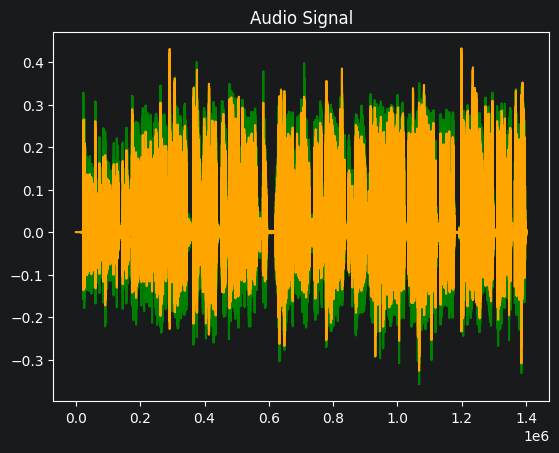

In [21]:
y, sr = librosa.load('/Users/d0304693/Documents/fun/als-voice-cloning-evaluation/data/DeepFilterNet/lufus/AUDIO-2021-07-30-06-44-26.wav')

y1, sr1 = librosa.load('/Users/d0304693/Documents/fun/als-voice-cloning-evaluation/data/DeepFilterNet/AUDIO-2021-07-30-06-44-26.wav')

pd.Series(y).plot(title='Audio Signal', color='green')

pd.Series(y1).plot(title='Audio Signal', color='orange')

In [22]:
from pydub.silence import split_on_silence
from pydub import AudioSegment

### Calculate silence threshold

In [23]:
audio_files = glob(f'{LUFUS}/*.wav')

all_rms_db = []
per_file_stats = []
print(len(audio_files))

42


In [24]:
for f in audio_files:
    y, sr = librosa.load(f, sr=24000)

    # calculate root mean square (RMS) energy for each frame of the audio signal
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=1024)[0]
    # convertion to dezibel
    rms_db = 20 * np.log10(rms + 1e-10)

    all_rms_db.extend(rms_db)

    # Calculate noise floor and speech level using percentiles to get a more robust estimate
    noise_floor = np.percentile(rms_db, 10)
    speech_level = np.percentile(rms_db, 80)


    per_file_stats.append({
        'file': f.split('/')[-1],
        'noise_floor': noise_floor,
        'speech_level': speech_level,
    })
all_rms_db = np.array(all_rms_db)

> Note: I calculated the noise floor with the percentile method instead of min or max method because it is more robust against outliers.

In [26]:
#  lower 10 % = Silence / Noise Floor
global_noise = np.percentile(all_rms_db, 10)
# upper 20 % = Speech Level
global_speech = np.percentile(all_rms_db, 80)

thresh_percentile = (global_noise + global_speech) / 2

print(f'Global Threshold: {thresh_percentile:.2f} dB')

Global Threshold: -39.01 dB


In [27]:
for f in audio_files:

    y, sr = librosa.load(f, sr=24000)

    aud = AudioSegment.from_file(f).set_channels(1).set_frame_rate(24000)
    audio_chunks = split_on_silence(
        aud,
        min_silence_len = 800,
        silence_thresh = -39,
        keep_silence = 200)

    if not audio_chunks:
        print(f"No chunks found for {f}, skipping.")
        continue

    processed_seg = audio_chunks[0]
    for chunk in audio_chunks[1:]:
        processed_seg += chunk

    output_name = os.path.splitext(os.path.basename(f))[0]
    output_path = f"{SILENCE}/{output_name}.wav"
    processed_seg.export(output_path, format="wav")

In [28]:
y1, sr1 = librosa.load('/Users/d0304693/Documents/fun/als-voice-cloning-evaluation/data/DeepFilterNet/lufus/AUDIO-2021-07-30-06-44-26.wav')

y, sr = librosa.load('/Users/d0304693/Documents/fun/als-voice-cloning-evaluation/data/DeepFilterNet/lufus/silence_removal/AUDIO-2021-07-30-06-44-26.wav')

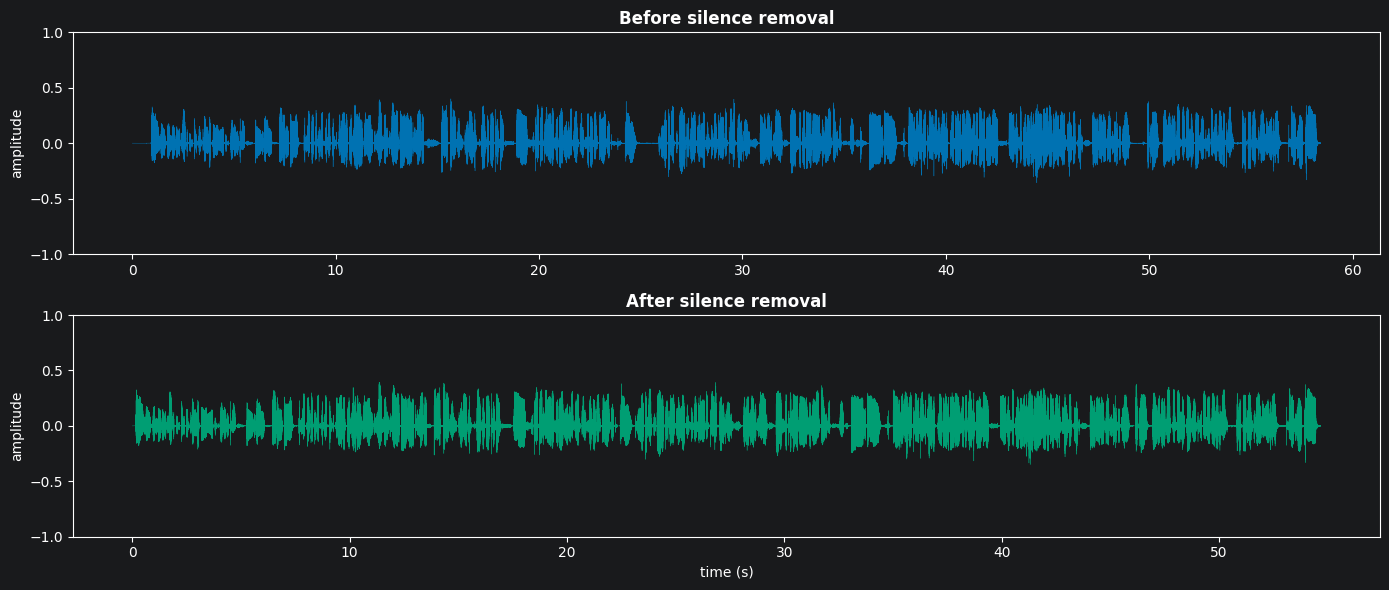

In [29]:
sr = 24000
t1 = np.arange(len(y1)) / sr
t2 = np.arange(len(y)) / sr

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(t1, y1, linewidth=0.3, color='#0072B2')
axes[0].set_title('Before silence removal', fontweight='bold')
axes[0].set_ylabel('amplitude')
axes[0].set_ylim(-1, 1)

axes[1].plot(t2, y, linewidth=0.3, color='#009E73')
axes[1].set_title('After silence removal', fontweight='bold')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('amplitude')
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

## Transcript audio and trim it into smaller chunks for fine-tuning

In [ ]:
device = "cuda"
audio_file = "audio.mp3"
batch_size = 16 # reduce if low on GPU mem
compute_type = "float16" # change to "int8" if low on GPU mem (may reduce accuracy)

In [ ]:
model = whisperx.load_model("large-v2", device, compute_type=compute_type)

dataset = []
for f in audio_files:
    audio = whisperx.load_audio(f)
    result = model.transcribe(audio, batch_size=batch_size)

    model_a, metadata = whisperx.load_align_model(language_code=result["language"], device=device)
    result = whisperx.align(result["segments"], model_a, metadata, audio, device, return_char_alignments=False)

    audio_segment = AudioSegment.from_file(f)

    for i, segment in enumerate(result["segments"]):
        start_ms = int(segment["start"] * 1000)
        end_ms = int(segment["end"] * 1000)
        text = segment["text"].strip()

        audio_file = os.path.basename(f).split('.')[0]

        if (end_ms - start_ms) > 1000 and len(text) > 0:
            slice_name = f"{audio_file}_slice_{i}.wav"
            slice_path = os.path.join(slice_name)

            chunk = audio_segment[start_ms:end_ms]
            chunk.export(slice_path, format="wav")

            dataset.append({
                "audio": slice_path,
                "text": text,
                "ref_audio": audio_file
            })

output_filename = f'{SLICING}/train_raw.jsonl'

with open(output_filename, 'w', encoding='utf-8') as f:
    for item in dataset:
        json_line = json.dumps(item, ensure_ascii=False)
        f.write(json_line + '\n')

print(f"Data successfully saved to {output_filename} in JSONL format.")